# Aula 12 — Seaborn Estatístico: distribuições, correlação e desigualdade
Semana 6 | 50 min | Referências: VanderPlas, Cap. 4 (*Visualization with Matplotlib*) · dados POF 2017-18 (IBGE)

## 🎯 Objetivos de aprendizagem

Ao final desta aula você será capaz de:

- **Visualizar distribuições** com `histplot` e `kdeplot`, interpretando assimetria (média R$ 1.687 vs mediana R$ 1.155 na POF).
- **Comparar grupos** com `boxplot` (renda por escolaridade; urbano × rural) e ler Q1, mediana, Q3 e outliers.
- **Relacionar variáveis** com `scatterplot`/`regplot` (renda × gastos) e **resumir correlações** num heatmap (`vmin=-1, vmax=1`).
- **Fatiar padrões com facetas** (`catplot`): o mesmo gráfico repetido por subgrupo — urbano/rural em cada nível de escolaridade.

## 1. Por que seaborn (e o que ele resolve)

A média da renda per capita da POF é **R$ 1.687**; a mediana, **R$ 1.155**. Mesma
distribuição, dois números — a diferença é a assinatura da **desigualdade**:
poucas famílias ricas puxam a média para cima. Quem relata só a média mente sem
dizer mentira; quem mostra a **distribuição** conta a história completa.

O seaborn é a camada estatística sobre o Matplotlib que fizemos à mão na Aula 11:
histograma + densidade, boxplot, reta de tendência e heatmap de correlações em uma
linha, com eixos rotulados e estética consistente. E continua sendo Matplotlib:
`sns.histplot(..., ax=ax)` desenha no mesmo quadro da aula passada.

**Perguntas econômicas da aula**: (1) como é a distribuição de renda no Brasil?
(2) o gasto acompanha a renda? — a **Lei de Engel**: a participação da alimentação
cai de ~68% no tercil pobre para ~60% no tercil rico. (3) urbano e rural diferem
em todos os níveis de escolaridade?

In [1]:
# Setup — imports e padrões visuais usados na aula
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from pathlib import Path

plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
})
sns.set_theme(style="whitegrid", font_scale=1.0)  # tema estatístico do seaborn

DATA = Path("../data/csv")  # notebook mora em semana_06/

def brl(x):
    """Formata um número como moeda brasileira: R$ 1.234,56."""
    return f"R$ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

fmt_brl = FuncFormatter(lambda v, _: brl(v))

np.random.seed(42)  # reprodutibilidade quando houver aleatoriedade

In [2]:
# Dados da POF: morador (RENDA_PC, NIVEL_INST, ANOS_EST) + domicílio (UF, SITUACAO)
pof = pd.read_csv(DATA / "pof_morador.csv").merge(
    pd.read_csv(DATA / "pof_domicilio.csv"), on="household_id", validate="many_to_one"
)

# NIVEL_INST (1-7): sem instrução ... superior completo — rótulos para os gráficos
NIVEL_ROTULO = {1: "1 Sem instr.", 2: "2 Fund. incompl.", 3: "3 Fund. compl.",
                4: "4 Médio incompl.", 5: "5 Médio compl.",
                6: "6 Sup. incompl.", 7: "7 Sup. compl."}
pof["ESCOLARIDADE"] = pof["NIVEL_INST"].map(NIVEL_ROTULO)

print("media :", brl(pof["RENDA_PC"].mean()))
print("mediana:", brl(pof["RENDA_PC"].median()))
print("skew  :", round(pof["RENDA_PC"].skew(), 1), "(assimetria positiva forte)")
pof[["RENDA_PC", "ANOS_EST", "NIVEL_INST"]].describe().round(1)

media : R$ 1.687,01
mediana: R$ 1.154,64
skew  : 22.5 (assimetria positiva forte)


,RENDA_PC,ANOS_EST,NIVEL_INST
count,58039.0,58039.0,58039.0
mean,1687.0,8.2,3.5
std,2469.0,4.9,1.9
min,-1658.7,0.0,1.0
25%,671.0,5.0,2.0
50%,1154.6,9.0,3.0
75%,1895.5,12.0,5.0
max,237869.0,16.0,7.0


## 2. Distribuição da renda: `histplot`

O histograma conta quantas famílias caem em cada faixa (**bin**) de renda. Duas
escolhas governam o resultado: o número de bins (poucos = bloco; muitos = ruído)
e a escala do eixo. A renda tem **cauda direita longa**: pouquíssimas famílias
acima de R$ 10 mil achatam todo o resto na esquerda. A solução clássica do
economista é olhar a renda em **escala logarítmica**.

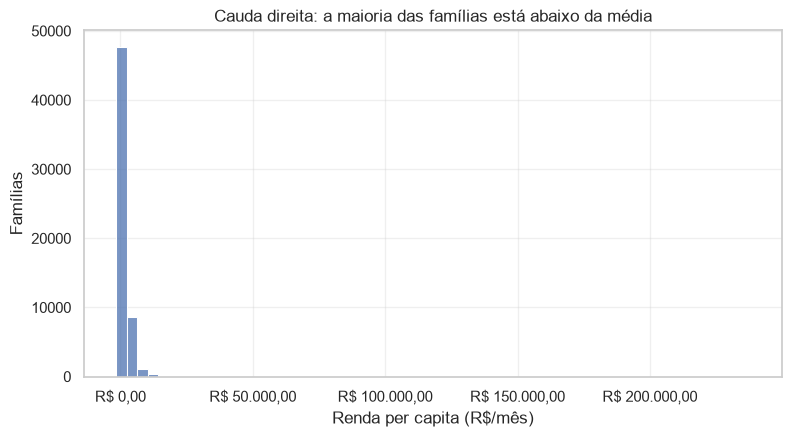

In [3]:
# Histograma linear: a cauda direita domina a escala
fig, ax = plt.subplots()
sns.histplot(data=pof, x="RENDA_PC", bins=60, color="#4c72b0", ax=ax)
ax.xaxis.set_major_formatter(fmt_brl)
ax.set_title("Cauda direita: a maioria das famílias está abaixo da média")
ax.set_xlabel("Renda per capita (R$/mês)")
ax.set_ylabel("Famílias")
plt.show()

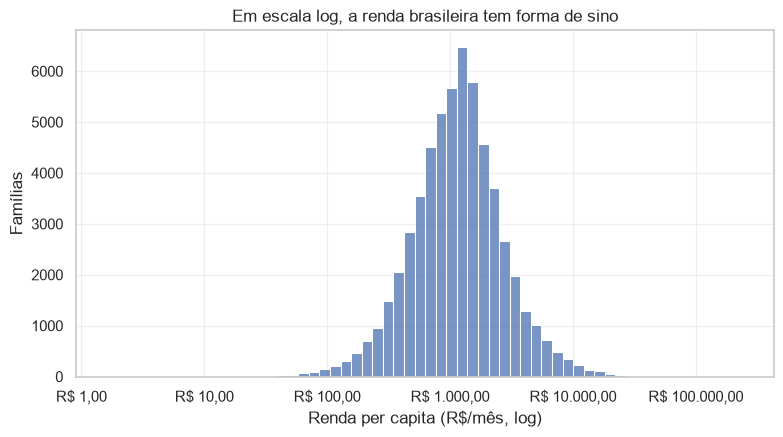

In [4]:
# Mesma distribuição em escala log — o "corpo" da distribuição aparece
fig, ax = plt.subplots()
sns.histplot(data=pof, x="RENDA_PC", bins=60, log_scale=True, color="#4c72b0", ax=ax)
ax.xaxis.set_major_formatter(fmt_brl)
ax.set_title("Em escala log, a renda brasileira tem forma de sino")
ax.set_xlabel("Renda per capita (R$/mês, log)")
ax.set_ylabel("Famílias")
plt.show()

## 3. Densidade e as duas medidas de centro: `kdeplot`

A curva de densidade (**KDE**) suaviza o histograma. **Cuidado**: o KDE padrão
extrapola para valores negativos, que não existem em renda — por isso `cut=0`.
Marcamos no gráfico a **mediana** e a **média**: a média cai à direita porque as
famílias ricas puxam-na para cima. Regra de bolso: média > mediana ⇒ cauda à direita.

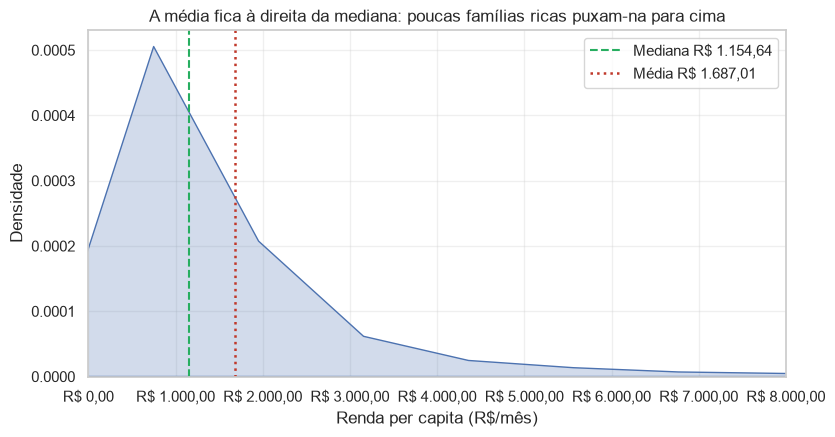

In [5]:
# Densidade da renda com as duas medidas de centro marcadas
fig, ax = plt.subplots()
sns.kdeplot(data=pof, x="RENDA_PC", fill=True, color="#4c72b0", cut=0, ax=ax)
ax.axvline(pof["RENDA_PC"].median(), color="#27ae60", ls="--", lw=1.5,
           label=f"Mediana {brl(pof['RENDA_PC'].median())}")
ax.axvline(pof["RENDA_PC"].mean(), color="#c0392b", ls=":", lw=1.8,
           label=f"Média {brl(pof['RENDA_PC'].mean())}")
ax.xaxis.set_major_formatter(fmt_brl)
ax.set_xlim(0, 8000)  # foco no corpo da distribuição (a cauda vai longe)
ax.set_title("A média fica à direita da mediana: poucas famílias ricas puxam-na para cima")
ax.set_xlabel("Renda per capita (R$/mês)")
ax.set_ylabel("Densidade")
ax.legend()
plt.show()

## 4. Comparando grupos: `boxplot` por escolaridade

O boxplot resume cinco números: **Q1** (25%), **mediana**, **Q3** (75%), limites
$Q_1 - 1{,}5\times\text{IQR}$ e $Q_3 + 1{,}5\times\text{IQR}$ e os **outliers**
além deles. Com ~58 mil domicílios, os outliers de renda achatam todas as caixas;
`showfliers=False` **não apaga dados da análise** — só da visualização.

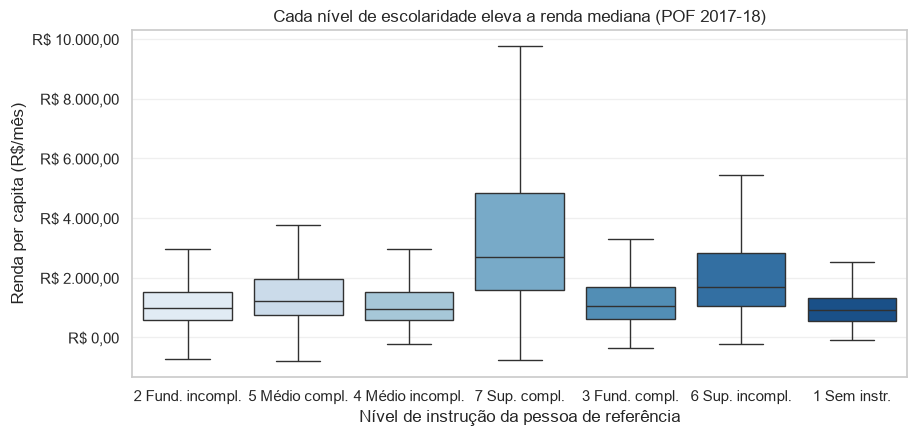

ESCOLARIDADE
1 Sem instr.          R$ 922,02
2 Fund. incompl.      R$ 986,94
3 Fund. compl.      R$ 1.069,37
4 Médio incompl.      R$ 940,99
5 Médio compl.      R$ 1.229,24
6 Sup. incompl.     R$ 1.698,01
7 Sup. compl.       R$ 2.707,32
Name: RENDA_PC, dtype: str

In [6]:
# Boxplot da renda por nível de instrução — gradiente monotônico
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.boxplot(data=pof, x="ESCOLARIDADE", y="RENDA_PC", showfliers=False, ax=ax,
            palette="Blues", hue="ESCOLARIDADE", legend=False)
ax.yaxis.set_major_formatter(fmt_brl)
ax.set_title("Cada nível de escolaridade eleva a renda mediana (POF 2017-18)")
ax.set_xlabel("Nível de instrução da pessoa de referência")
ax.set_ylabel("Renda per capita (R$/mês)")
plt.show()

# Números por trás do gráfico
pof.groupby("ESCOLARIDADE", observed=True)["RENDA_PC"].median().map(brl)

## 5. Renda × gastos: scatterplot e reta de tendência

Agora cruzamos renda com gasto anual por categoria
(`pof_despesa_categoria.csv`). Duas decisões econômicas:

1. **Amostra de 4.000 domicílios** com `alpha=0.3` — 57 mil pontos viram mancha preta;
2. Além do gasto **em reais** (cresce com a renda), a **participação da
   alimentação no gasto total** — que **cai** com a renda: a **Lei de Engel**.

In [7]:
# Merge com despesas + amostra legível para o scatter
cats = ["food", "housing", "transport", "health", "other"]
# pof_morador tem raras duplicatas de pessoa de referência -> 1 linha por domicílio
pof_1 = pof.drop_duplicates(subset="household_id")
pof_desp = pd.read_csv(DATA / "pof_despesa_categoria.csv").merge(
    pof_1, on="household_id", validate="one_to_one"
)
pof_desp["gasto_total"] = pof_desp[cats].sum(axis=1)
pof_desp["food_share"] = pof_desp["food"] / pof_desp["gasto_total"]

amostra = pof_desp.sample(4000, random_state=42)   # visualização apenas
print(f"{len(pof_desp):,} domicílios com renda + gasto; amostra de {len(amostra):,}")

57,799 domicílios com renda + gasto; amostra de 4,000


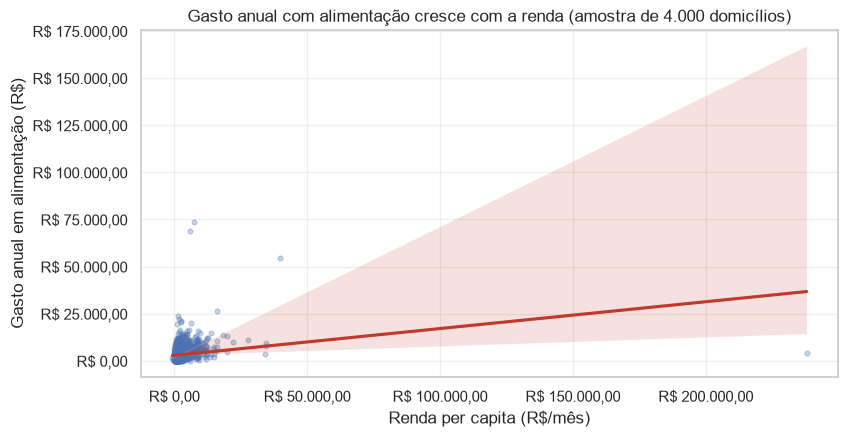

Correlação renda × food: 0.294


In [8]:
# Scatter renda × gasto anual em alimentação, com reta de tendência
fig, ax = plt.subplots()
sns.regplot(data=amostra, x="RENDA_PC", y="food",
            scatter_kws={"s": 12, "alpha": 0.3}, line_kws={"color": "#c0392b"}, ax=ax)
ax.xaxis.set_major_formatter(fmt_brl)
ax.yaxis.set_major_formatter(fmt_brl)
ax.set_title("Gasto anual com alimentação cresce com a renda (amostra de 4.000 domicílios)")
ax.set_xlabel("Renda per capita (R$/mês)")
ax.set_ylabel("Gasto anual em alimentação (R$)")
plt.show()
print("Correlação renda × food:", round(pof_desp["RENDA_PC"].corr(pof_desp["food"]), 3))

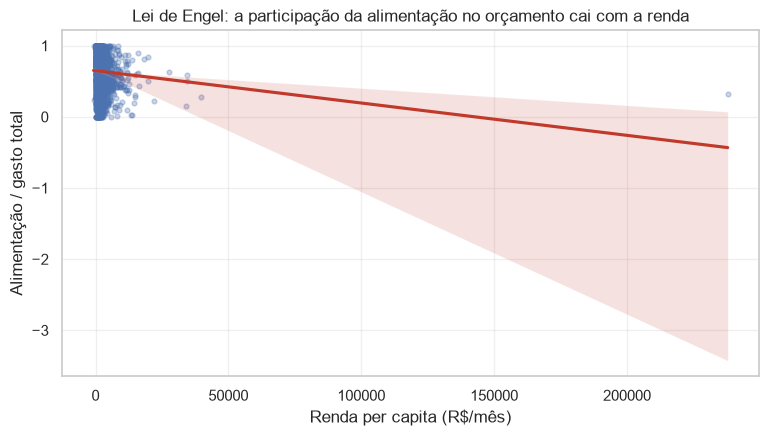

faixa
pobre    0.682
meio     0.653
rico     0.602
Name: food_share, dtype: float64

In [9]:
# Lei de Engel: a PARTICIPAÇÃO da alimentação cai quando a renda sobe
fig, ax = plt.subplots()
sns.regplot(data=amostra, x="RENDA_PC", y="food_share",
            scatter_kws={"s": 12, "alpha": 0.3}, line_kws={"color": "#c0392b"}, ax=ax)
ax.set_title("Lei de Engel: a participação da alimentação no orçamento cai com a renda")
ax.set_xlabel("Renda per capita (R$/mês)")
ax.set_ylabel("Alimentação / gasto total")
plt.show()

# Evidência por tercil de renda
pof_desp["faixa"] = pd.qcut(pof_desp["RENDA_PC"], 3, labels=["pobre", "meio", "rico"])
pof_desp.groupby("faixa", observed=True)["food_share"].mean().round(3)

## 6. Correlações entre categorias: heatmap

O heatmap colore a matriz de correlações de Pearson. Duas regras de relatório:
**sempre** `vmin=-1, vmax=1` (a cor só significa algo com escala fixa) e
**correlação não é causalidade** — todas as correlações aqui são positivas
(famílias maiores e mais ricas gastam mais em *tudo*), o efeito renda/tamanho.

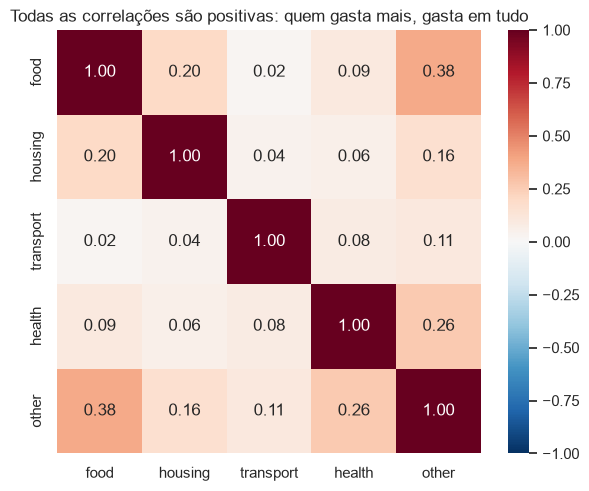

Correlação mais forte: ('food', 'other')


In [10]:
# Heatmap de correlação entre categorias de gasto
corr = pof_desp[cats].corr()
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1,
            square=True, ax=ax)
ax.set_title("Todas as correlações são positivas: quem gasta mais, gasta em tudo")
plt.show()
print("Correlação mais forte:", corr.mask(np.eye(len(corr), dtype=bool)).stack().idxmax())

## 7. Urbano × rural: boxplot e facetas

A renda urbana média (**R$ 1.814**) supera a rural (**R$ 1.253**) em R$ 562/mês.
O boxplot compara os dois grupos; o `catplot` com `col="SITUACAO"` (faceta) repete
o gráfico da renda por escolaridade **dentro de cada situação** — a pergunta de
economista é "o padrão se mantém nos subgrupos?"

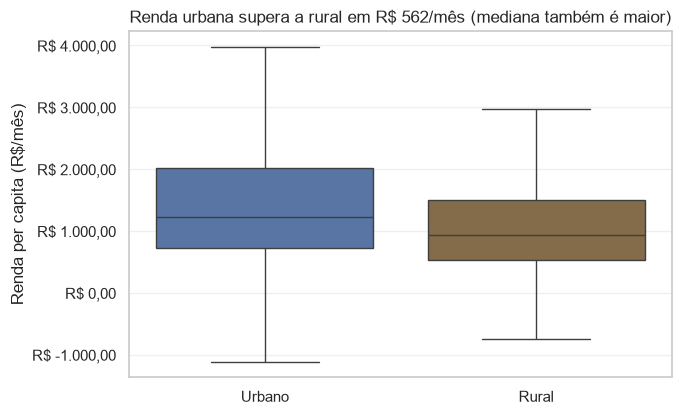

,mean,median
SIT_ROTULO,,
Rural,1253.0,937.0
Urbano,1814.0,1222.0


In [11]:
# Boxplot da renda: urbano vs rural
pof["SIT_ROTULO"] = pof["SITUACAO"].map({1: "Urbano", 2: "Rural"})
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(data=pof, x="SIT_ROTULO", y="RENDA_PC", showfliers=False,
            hue="SIT_ROTULO", palette=["#4c72b0", "#8e6c3f"], legend=False, ax=ax)
ax.yaxis.set_major_formatter(fmt_brl)
ax.set_title("Renda urbana supera a rural em R$ 562/mês (mediana também é maior)")
ax.set_xlabel("")
ax.set_ylabel("Renda per capita (R$/mês)")
plt.show()
pof.groupby("SIT_ROTULO")["RENDA_PC"].agg(["mean", "median"]).round(0)

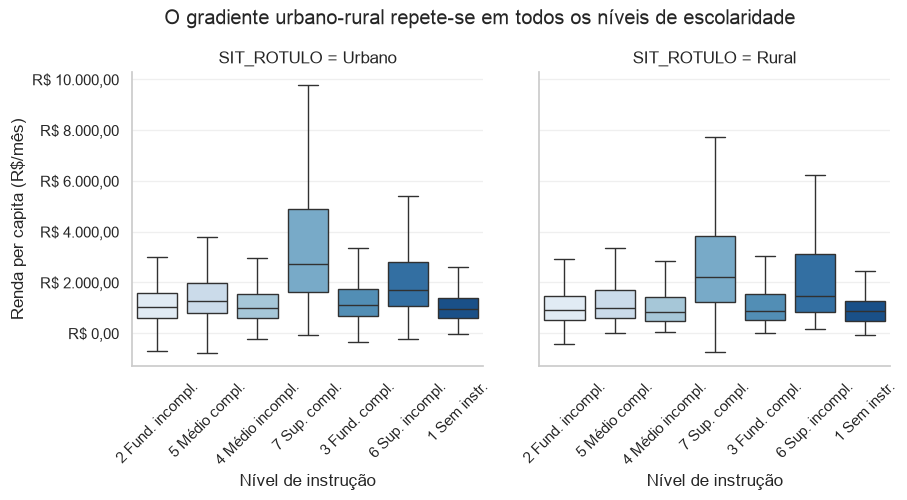

In [12]:
# Facetas: renda por escolaridade, repetida para urbano e rural
g = sns.catplot(data=pof, kind="box", x="ESCOLARIDADE", y="RENDA_PC",
                col="SIT_ROTULO", showfliers=False, height=4, aspect=1.1,
                palette="Blues", hue="ESCOLARIDADE", legend=False)
g.set_axis_labels("Nível de instrução", "Renda per capita (R$/mês)")
g.figure.suptitle("O gradiente urbano-rural repete-se em todos os níveis de escolaridade",
                  y=1.06)
g.set_xticklabels(rotation=45)
for ax in g.axes.flat:                     # FacetGrid tem VÁRIOS eixos
    ax.yaxis.set_major_formatter(fmt_brl)
plt.show()

## 📝 Exercícios

Tente antes de abrir a solução. Usam os objetos já criados
(`pof`, `pof_desp`, `fmt_brl`, `brl`, `cats`).

### Exercício 1 — Brasil × Goiás sobrepostos

Sobreponha **dois histogramas de densidade** (`stat="density"`) da RENDA_PC:
Brasil inteiro vs apenas Goiás (UF = 52). Sem `stat="density"` a comparação
quebra — por quê? Goiás acompanha o padrão nacional?

In [13]:
# EXERCÍCIO 1 — seu código aqui

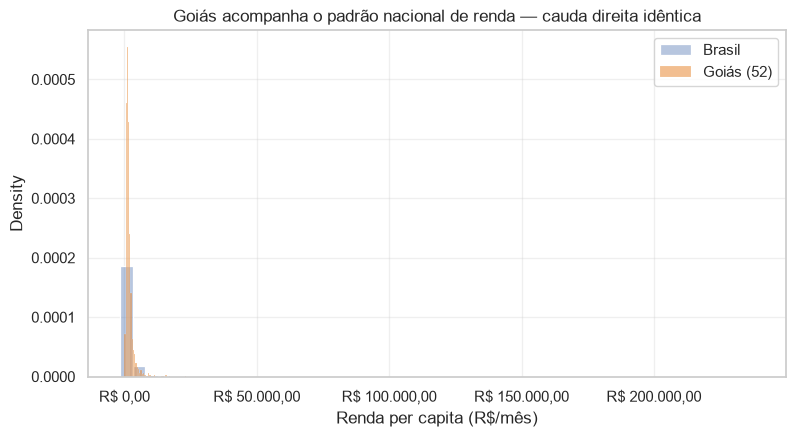

Mediana BR: R$ 1.154,64 | mediana GO: R$ 1.313,32


In [14]:
# SOLUÇÃO 1 — densidades Brasil x Goiás sobrepostas
go = pof[pof["UF"] == 52]
fig, ax = plt.subplots()
sns.histplot(data=pof, x="RENDA_PC", bins=50, stat="density",
             color="#4c72b0", alpha=0.4, label="Brasil", ax=ax)
sns.histplot(data=go, x="RENDA_PC", bins=50, stat="density",
             color="#e67e22", alpha=0.5, label="Goiás (52)", ax=ax)
ax.xaxis.set_major_formatter(fmt_brl)
ax.set_title("Goiás acompanha o padrão nacional de renda — cauda direita idêntica")
ax.set_xlabel("Renda per capita (R$/mês)")
ax.legend()
plt.show()
print("Mediana BR:", brl(pof['RENDA_PC'].median()), "| mediana GO:", brl(go['RENDA_PC'].median()))

### Exercício 2 — Renda por faixa de anos de estudo

Com `pd.cut`, crie 3 faixas de `ANOS_EST` (até 4, 5–11, 12 ou mais) e desenhe o
boxplot da RENDA_PC por faixa (`showfliers=False`). O gradiente é monotônico?

In [15]:
# EXERCÍCIO 2 — seu código aqui

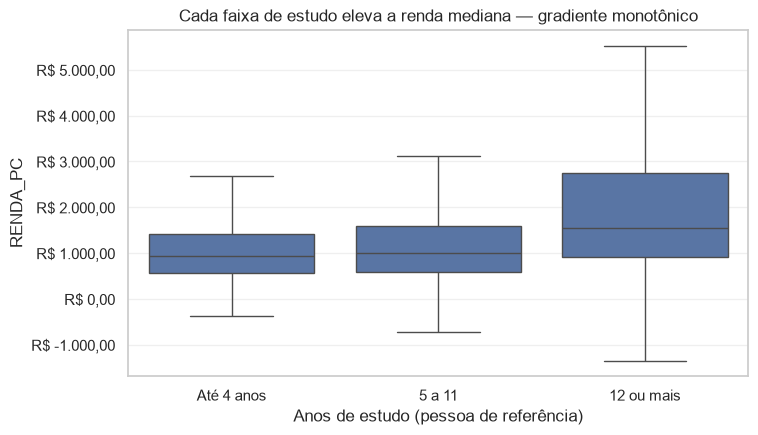

ESTUDO_FAIXA
Até 4 anos      R$ 942,56
5 a 11        R$ 1.011,98
12 ou mais    R$ 1.557,11
Name: RENDA_PC, dtype: str

In [16]:
# SOLUÇÃO 2 — boxplot da renda por faixa de anos de estudo
pof["ESTUDO_FAIXA"] = pd.cut(pof["ANOS_EST"], bins=[-1, 4, 11, np.inf],
                             labels=["Até 4 anos", "5 a 11", "12 ou mais"])
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=pof, x="ESTUDO_FAIXA", y="RENDA_PC", showfliers=False, ax=ax,
            color="#4c72b0")
ax.yaxis.set_major_formatter(fmt_brl)
ax.set_title("Cada faixa de estudo eleva a renda mediana — gradiente monotônico")
ax.set_xlabel("Anos de estudo (pessoa de referência)")
plt.show()
pof.groupby("ESTUDO_FAIXA", observed=True)["RENDA_PC"].median().map(brl)

### Exercício 3 — Transporte: o gasto que acelera com a renda

Repita o `regplot` da seção 5 trocando `food` por `transport`. Compare as
inclinações: enquanto alimentação é necessity (participação cai), o que se diz
do transporte? Calcule a correlação renda × transporte.

In [17]:
# EXERCÍCIO 3 — seu código aqui

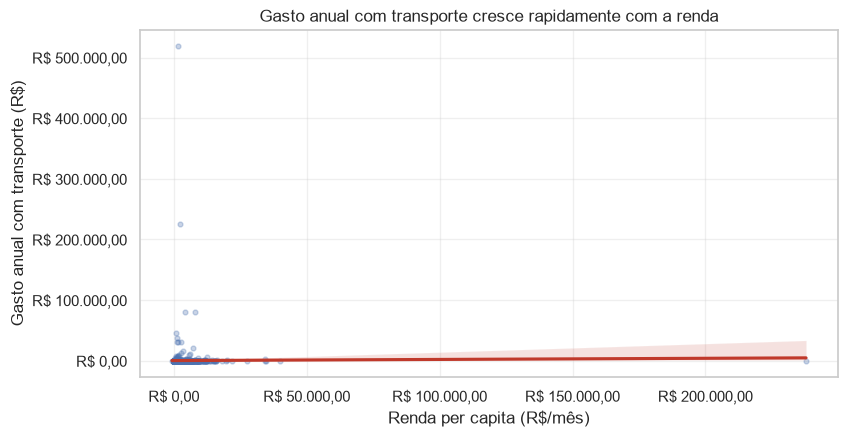

Correlação renda × transporte: 0.078


In [18]:
# SOLUÇÃO 3 — regplot renda x transporte
amostra2 = pof_desp.sample(4000, random_state=42)
fig, ax = plt.subplots()
sns.regplot(data=amostra2, x="RENDA_PC", y="transport",
            scatter_kws={"s": 12, "alpha": 0.3}, line_kws={"color": "#c0392b"}, ax=ax)
ax.xaxis.set_major_formatter(fmt_brl)
ax.yaxis.set_major_formatter(fmt_brl)
ax.set_title("Gasto anual com transporte cresce rapidamente com a renda")
ax.set_xlabel("Renda per capita (R$/mês)")
ax.set_ylabel("Gasto anual com transporte (R$)")
plt.show()
print("Correlação renda × transporte:",
      round(pof_desp["RENDA_PC"].corr(pof_desp["transport"]), 3))

### Exercício 4 — Correlações urbano × rural, lado a lado

Dois heatmaps da matriz de correlações das categorias — um para domicílios
urbanos (`SITUACAO == 1`), outro para rurais (`== 2`) — em `plt.subplots(1, 2)`
com a **mesma escala** (`vmin=-1, vmax=1, cbar=False`). O padrão de correlações
difere entre os grupos?

In [19]:
# EXERCÍCIO 4 — seu código aqui

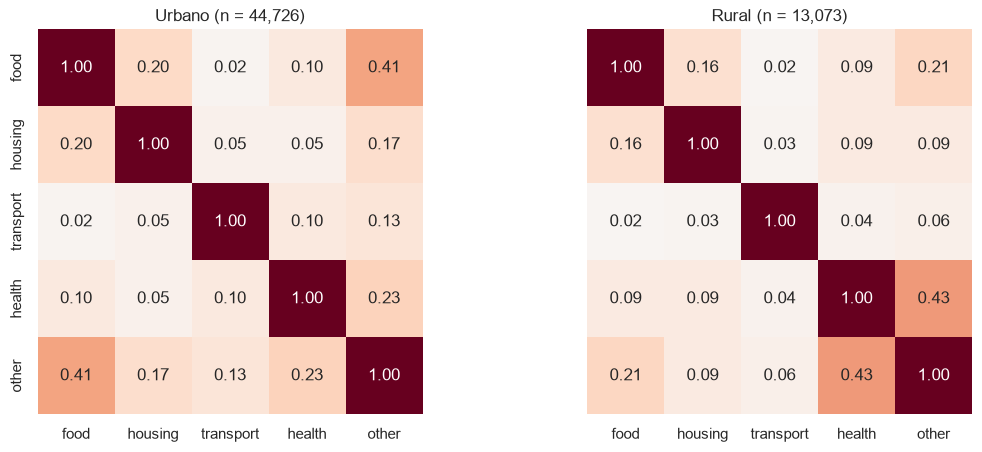

In [20]:
# SOLUÇÃO 4 — heatmaps urbano x rural com escala compartilhada
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, sit, titulo in [(axes[0], 1, "Urbano"), (axes[1], 2, "Rural")]:
    sub = pof_desp[pof_desp["SITUACAO"] == sit]
    sns.heatmap(sub[cats].corr(), annot=True, fmt=".2f", cmap="RdBu_r",
                vmin=-1, vmax=1, square=True, cbar=False, ax=ax)
    ax.set_title(f"{titulo} (n = {len(sub):,})")
plt.show()

## 📌 Resumo & para casa

- **Distribuição antes de média**: histograma/densidade revelam a assimetria que a média esconde (POF: média R$ 1.687 > mediana R$ 1.155; skew ≈ 22).
- **`kdeplot` de renda sempre com `cut=0`** — a curva padrão extrapola para renda negativa, que não existe.
- **`boxplot` lê cinco números** (Q1, mediana, Q3, limites 1,5×IQR, outliers); `showfliers=False` limpa só a visualização, não a análise.
- **Lei de Engel na POF**: participação da alimentação cai de ~68% (tercil pobre) para ~60% (tercil rico) — gasto em reais sobe, participação desce.
- **Heatmap sempre com `vmin=-1, vmax=1`**; correlação descreve co-movimento, não causa.
- **Facetas** (`catplot(col=...)`) respondem "o padrão se mantém nos subgrupos?" — e iterar `g.axes.flat` aplica formatter de reais em todos os painéis.
- **Para casa**: escolha uma categoria de gasto e escreva 3 frases de relatório sobre sua relação com a renda (nível, inclinação, correlação) — sem dizer "correlação implica causa".
- **Próxima aula**: laboratório completo com os microdados da POF (Aula 13).

**Referências (KB)**:
- `kb/02_vanderplas_python_data_science_handbook/07_chapter-4-visualization-with-matplotlib.md`